# Libraries


In [1]:
import pandas as pd 

import numpy as np

import seaborn as sns

import matplotlib.pyplot as plt

import sklearn as sk

import statsmodels.api as sm 

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_squared_error, r2_score

from io import StringIO

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Importng and cleaning the dataset

house_original = pd.read_csv(r"C:\Users\DELL\OneDrive\Desktop\Python_Projects\housing_prediction_cleaned.csv" )


house_copied = house_original
house_copied.columns 

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV', 'RM2', 'LSTAT_bin', 'CRIM_log',
       'PRICE_per_ROOM'],
      dtype='object')

In [4]:
print("Info: \n", house_copied.info())

 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CRIM            506 non-null    float64
 1   ZN              506 non-null    float64
 2   INDUS           506 non-null    float64
 3   CHAS            506 non-null    int64  
 4   NOX             506 non-null    float64
 5   RM              506 non-null    float64
 6   AGE             506 non-null    float64
 7   DIS             506 non-null    float64
 8   RAD             506 non-null    int64  
 9   TAX             506 non-null    float64
 10  PTRATIO         506 non-null    float64
 11  B               506 non-null    float64
 12  LSTAT           506 non-null    float64
 13  MEDV            506 non-null    float64
 14  RM2             506 non-null    float64
 15  LSTAT_bin       506 non-null    int64  
 16  CRIM_log        506 non-null    float64
 17  PRICE_per_ROOM  506 non-null    flo

In [5]:
print(house_copied.head(5))



      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  MEDV        RM2  LSTAT_bin  CRIM_log  \
0     15.3  396.90   4.98  24.0  43.230625          0  0.006300   
1     17.8  396.90   9.14  21.6  41.229241          1  0.026944   
2     17.8  392.83   4.03  34.7  51.624225          0  0.026924   
3     18.7  394.63   2.94  33.4  48.972004          0  0.031857   
4     18.7  396.90   5.33  36.2  51.079609          0  0.066770   

   PRICE_per_ROOM  
0        3.650190  
1        3.363962  
2        4.829506  
3        4.772792  
4        5.065062  


In [6]:
print("Shape:  \n", house_copied.shape)

Shape:  
 (506, 18)


#### Predicting  MEDV from LSTAT 

In [7]:


X_house = house_copied[['LSTAT']]  #independent

y_house = house_copied[['MEDV']]  # dependent




In [ ]:
# Train / Test split


X_house_train, X_house_test, y_house_train, y_house_test = train_test_split(
    X_house, y_house, test_size= 0.2, random_state= 42
    )






In [ ]:
# Fitting linear regression model


model_house = LinearRegression()
model_house.fit(X_house_train, y_house_train)


intercept = model_house.intercept_[0]
slope = model_house.coef_[0][0]



print(f"Model equation:  LSTAT = {slope:.3f} x MEDV + {intercept:.3f} \n")





Model equation:  LSTAT = -0.874 x MEDV + 32.972 



In [10]:
# Making predictions on test set
y_house_pred = model_house.predict(X_house_test)
y_house_pred




array([[25.07350417],
       [29.88756472],
       [17.18403651],
       [28.14891127],
       [17.88299267],
       [22.51357723],
       [16.95687576],
       [11.86323274],
       [21.72725155],
       [20.45165656],
       [17.31509079],
       [18.03152085],
       [ 5.04622595],
       [22.19031001],
       [22.71452713],
       [22.78442274],
       [17.61214716],
       [ 6.21916175],
       [30.37683403],
       [17.1316148 ],
       [27.21405741],
       [26.68984029],
       [13.22619725],
       [24.52307619],
       [19.25469413],
       [17.12287785],
       [25.02108245],
       [16.62487158],
       [17.88299267],
       [20.65260645],
       [20.13712629],
       [26.68110333],
       [21.22924529],
       [24.06875469],
       [14.34452711],
       [19.17606157],
       [29.45071712],
       [24.40949581],
       [20.16333714],
       [26.38404697],
       [14.50179225],
       [26.39278392],
       [30.4554666 ],
       [21.53503861],
       [25.27445406],
       [18

In [ ]:
# Evaluating the model


print("Test set performance:")

print ("•Intercept: \n", round(model_house.intercept_[0], 3))

print ("•Coefficient: \n", round(model_house.coef_[0] [0], 3),)

print ("•R²: \n", round(r2_score(y_house_test,y_house_pred), 3))

print("•RMSE: \n", round(np.sqrt(mean_squared_error(y_house_test,y_house_pred)),3))

Test set performance:
•Intercept: 
 32.972
•Coefficient: 
 -0.874
•R²: 
 0.665
•RMSE: 
 4.049


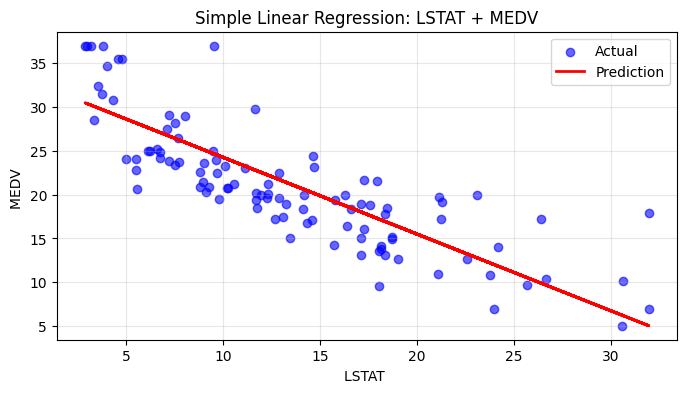

In [ ]:
# Visualizing it 


plt.figure(figsize=(8,4))
plt.scatter(X_house_test, y_house_test, color='blue', label='Actual', alpha=0.6)
plt.plot(X_house_test, y_house_pred, color='red', linewidth=2, label='Prediction')
plt.xlabel('LSTAT ')
plt.ylabel('MEDV ')
plt.title('Simple Linear Regression: LSTAT + MEDV')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()